PREPAPE EVN

In [1]:
!pip install --upgrade torch_geometric

!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:0000:01
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 96.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 98.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 86.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 80.0 MB/s eta 0:00:00:00:01


K-fold, increasing learning, full report

Running on: cuda

[Step 1] Loading Data...
   -> Sorting data by Timestep to ensure strict temporal order...
   -> Data Split Strategy:
      - Train/Val (K-Fold): Timesteps 1 to 39 (80%)
      - Final Test (Held-out): Timesteps 40 to 49 (20%)
   -> Scaling data...

[Step 2] Starting Incremental Training (Transfer Weights)...

==================== TRAINING Fold 1 ====================
    Train: 1 -> 15
    Valid: 16 -> 20
    [INFO] First fold: Training from scratch.

[REPORT] Fold 1 (Best Thr: 0.35)
              precision    recall  f1-score   support

       Licit       0.91      0.95      0.93      2756
     Illicit       0.73      0.60      0.66       619

    accuracy                           0.89      3375
   macro avg       0.82      0.77      0.79      3375
weighted avg       0.88      0.89      0.88      3375

ROC AUC: 0.9167
Confusion Matrix:
[[2622  134]
 [ 250  369]]


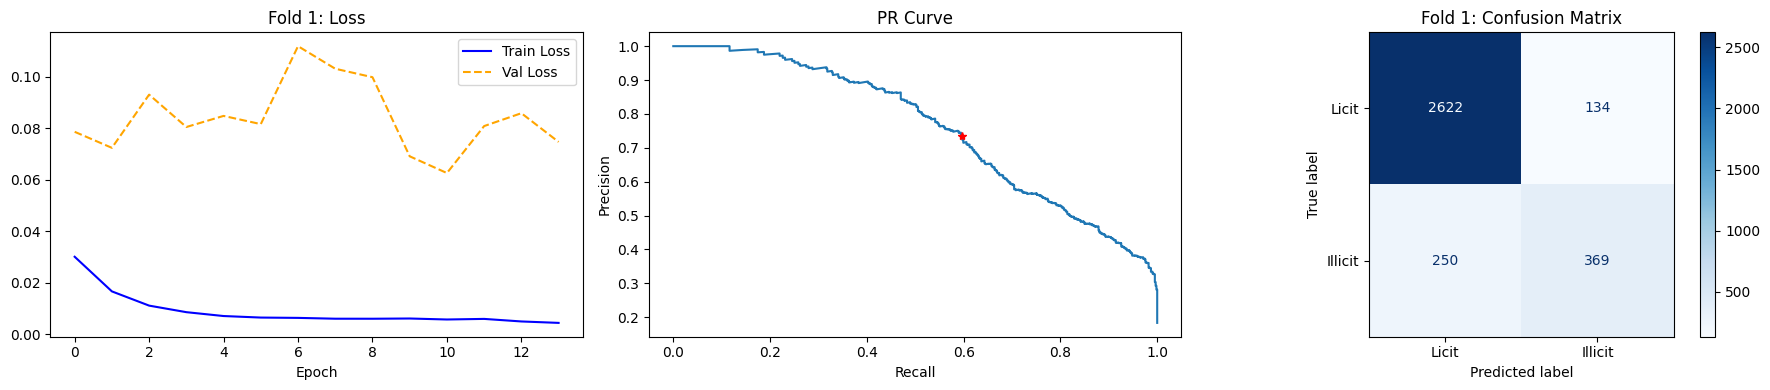


==================== TRAINING Fold 2 ====================
    Train: 1 -> 20
    Valid: 21 -> 25
    [INFO] Loaded weights from previous fold.

[REPORT] Fold 2 (Best Thr: 0.60)
              precision    recall  f1-score   support

       Licit       0.96      0.97      0.97      4745
     Illicit       0.75      0.69      0.72       566

    accuracy                           0.94      5311
   macro avg       0.86      0.83      0.84      5311
weighted avg       0.94      0.94      0.94      5311

ROC AUC: 0.9007
Confusion Matrix:
[[4617  128]
 [ 176  390]]


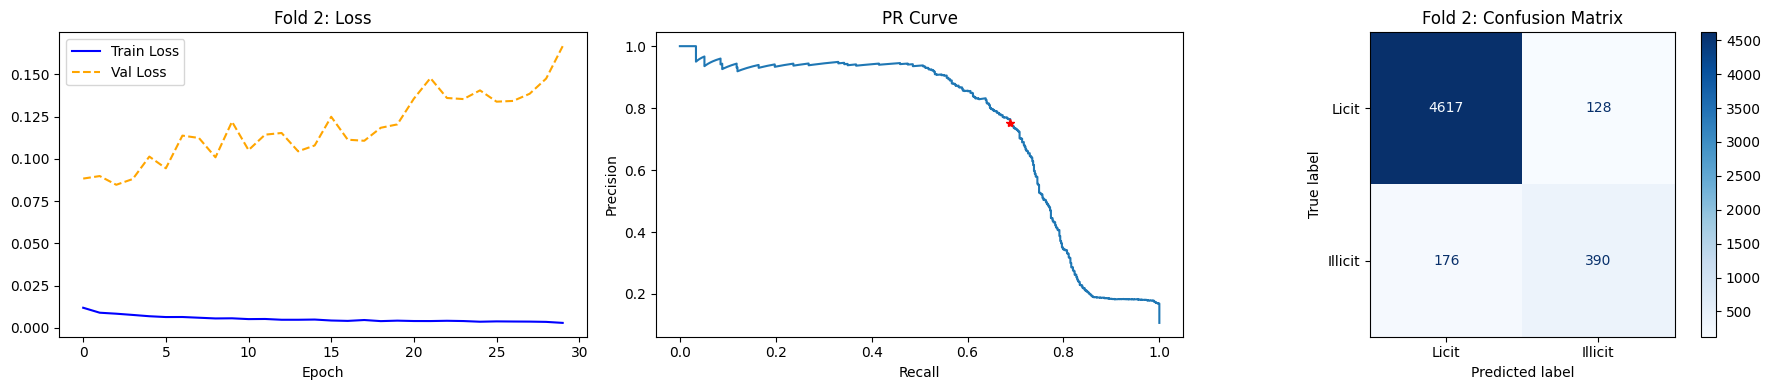


==================== TRAINING Fold 3 ====================
    Train: 1 -> 25
    Valid: 26 -> 30
    [INFO] Loaded weights from previous fold.

[REPORT] Fold 3 (Best Thr: 0.50)
              precision    recall  f1-score   support

       Licit       0.97      0.97      0.97      2088
     Illicit       0.91      0.90      0.90       617

    accuracy                           0.96      2705
   macro avg       0.94      0.94      0.94      2705
weighted avg       0.96      0.96      0.96      2705

ROC AUC: 0.9824
Confusion Matrix:
[[2032   56]
 [  61  556]]


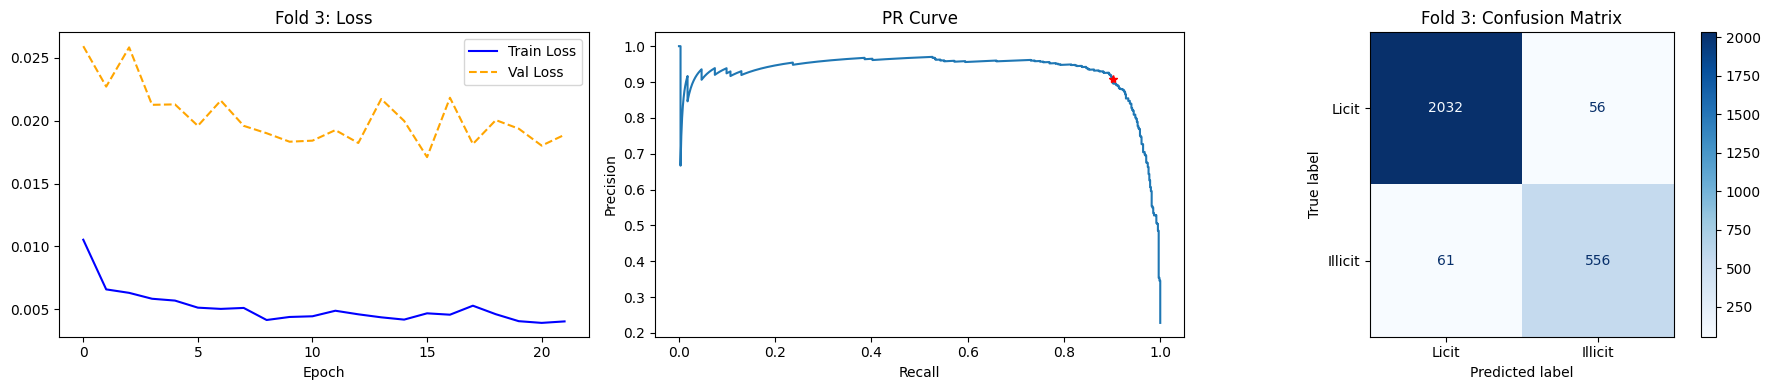


==================== TRAINING Fold 4 ====================
    Train: 1 -> 30
    Valid: 31 -> 35
    [INFO] Loaded weights from previous fold.

[REPORT] Fold 4 (Best Thr: 0.50)
              precision    recall  f1-score   support

       Licit       0.98      0.96      0.97      3640
     Illicit       0.81      0.88      0.84       690

    accuracy                           0.95      4330
   macro avg       0.89      0.92      0.91      4330
weighted avg       0.95      0.95      0.95      4330

ROC AUC: 0.9710
Confusion Matrix:
[[3498  142]
 [  83  607]]


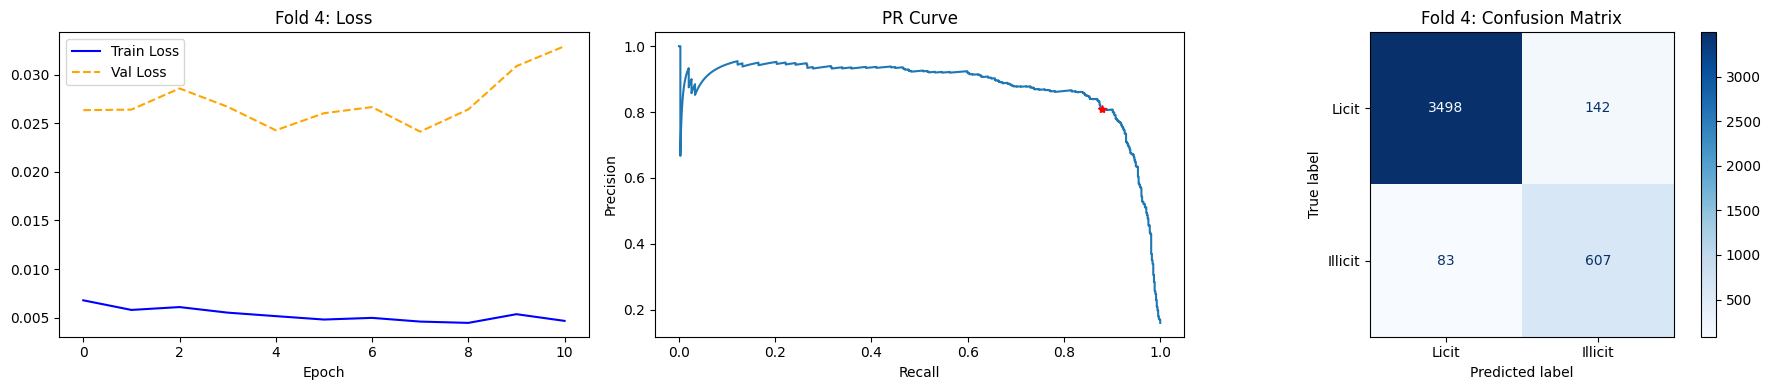


==================== TRAINING Fold 5 (Last 80%) ====================
    Train: 1 -> 35
    Valid: 36 -> 39
    [INFO] Loaded weights from previous fold.

[REPORT] Fold 5 (Last 80%) (Best Thr: 0.45)
              precision    recall  f1-score   support

       Licit       0.99      0.99      0.99      3880
     Illicit       0.83      0.79      0.81       265

    accuracy                           0.98      4145
   macro avg       0.91      0.89      0.90      4145
weighted avg       0.98      0.98      0.98      4145

ROC AUC: 0.9778
Confusion Matrix:
[[3837   43]
 [  56  209]]


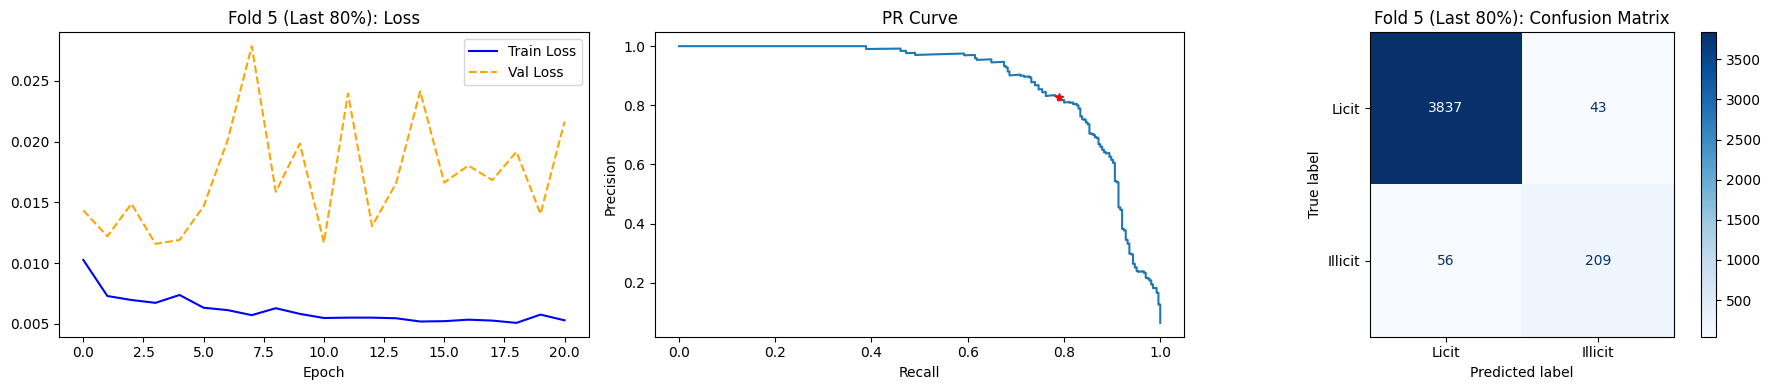


[Step 3] Final Test on Held-out Data (Timestep 40-49)...

   FINAL TEST REPORT (20% Held-out)
Optimal Threshold: 0.50
              precision    recall  f1-score   support

       Licit       0.97      1.00      0.98     10548
     Illicit       0.88      0.50      0.64       636

    accuracy                           0.97     11184
   macro avg       0.92      0.75      0.81     11184
weighted avg       0.97      0.97      0.96     11184

Test ROC AUC: 0.8663
Confusion Matrix:
[[10504    44]
 [  318   318]]


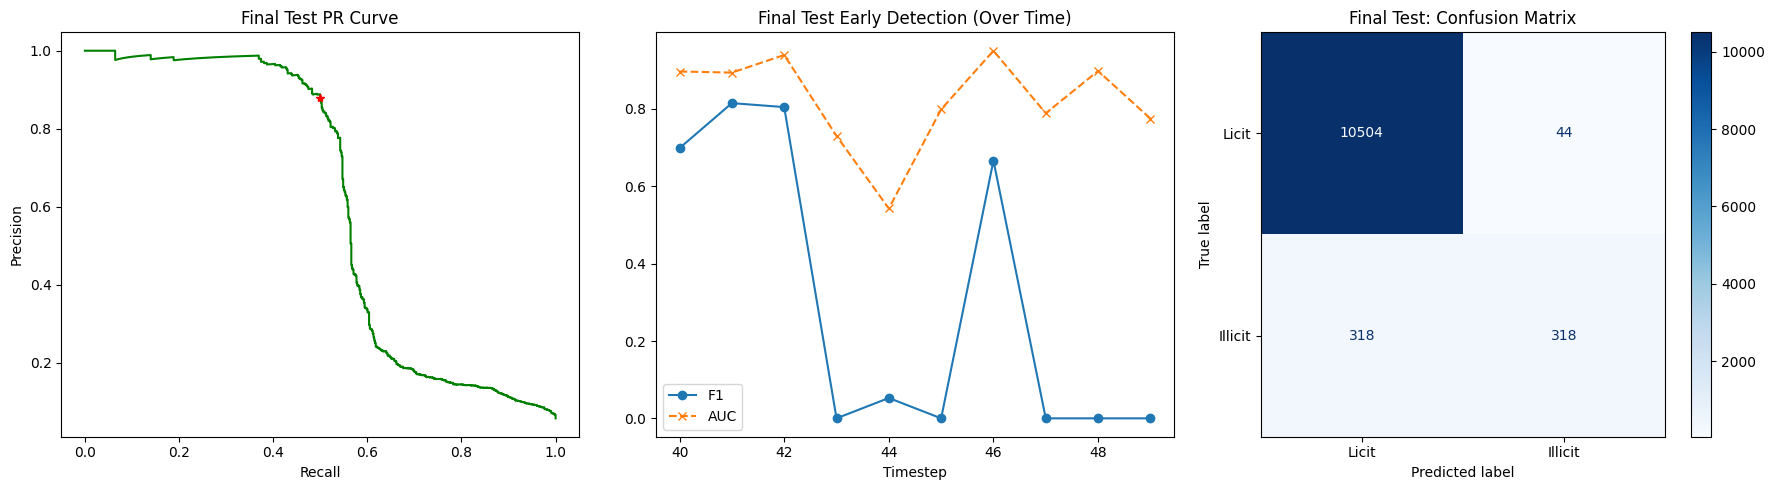

In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
# [UPDATE] Thêm ConfusionMatrixDisplay vào imports
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math
import random
import os
import shutil
import gc

# --- 0. REPRODUCIBILITY ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(80)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. LOAD & PROCESS DATA ---
print("\n[Step 1] Loading Data...")
try:
    base_path = '/kaggle/input/elliptic/elliptic/' 
    df_features = pd.read_csv(base_path + 'elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv(base_path + 'elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv(base_path + 'elliptic_txs_edgelist.csv')
except:
    try:
        df_features = pd.read_csv('elliptic_txs_features.csv', header=None)
        df_classes = pd.read_csv('elliptic_txs_classes.csv')
        df_edgelist = pd.read_csv('elliptic_txs_edgelist.csv')
    except:
        print("Error: CSV files not found.")
        exit()

# 1.1 Merge & Format
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})

# --- [CRITICAL] 1.2 SORT DATA BY TIME ---
print("   -> Sorting data by Timestep to ensure strict temporal order...")
df_merged = df_merged.sort_values(by=['timestep', 'txId']).reset_index(drop=True)

# 1.3 Re-Map IDs after sorting
all_tx_ids = df_merged['txId'].values
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

# 1.4 Define 80/20 Split based on Timestep
features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

total_timesteps = df_merged['timestep'].max() # Should be 49
split_timestep = int(total_timesteps * 0.8)   # 39

print(f"   -> Data Split Strategy:")
print(f"      - Train/Val (K-Fold): Timesteps 1 to {split_timestep} (80%)")
print(f"      - Final Test (Held-out): Timesteps {split_timestep+1} to {total_timesteps} (20%)")

# 1.5 Scaling (Fit ONLY on 80% Data)
print("   -> Scaling data...")
scaler = StandardScaler()
fit_idx = X_df.index[timesteps <= split_timestep].values
scaler.fit(X_df.loc[fit_idx])
X_scaled = scaler.transform(X_df)

# 1.6 Create Graph Object
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.fillna(-1).values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)

del df_features, df_classes, df_edgelist, df_merged, X_df, X_scaled
gc.collect()

# --- 2. MODEL COMPONENTS ---
class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.2):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.lin_q = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_k = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_v = nn.Linear(in_channels + time_channels, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)
    def forward(self, x, edge_index, t_emb):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)
        out = self.propagate(edge_index, q=q, k=k, v=v, size=None)
        out = out.view(-1, self.heads * self.head_dim) + self.lin_skip(x)
        return out
    def message(self, q_i, k_j, v_j, index, ptr, size_i):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class RobustTGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=4, dropout=0.3)
        self.lin_out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.3) 
    def forward(self, x, edge_index, t):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index, t_emb))
        x = self.dropout(x)
        return self.lin_out(x)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0): 
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alphas = torch.where(targets == 1, self.alpha, 1.0 - self.alpha)
        return torch.mean(alphas * (1-pt)**self.gamma * ce_loss)

# --- 3. INCREMENTAL K-FOLD (ON 80% DATA: TS 1-39) ---
# Define folds within the 1-39 range
folds = [
    {'name': 'Fold 1', 'train_end': 15, 'val_start': 16, 'val_end': 20},
    {'name': 'Fold 2', 'train_end': 20, 'val_start': 21, 'val_end': 25},
    {'name': 'Fold 3', 'train_end': 25, 'val_start': 26, 'val_end': 30},
    {'name': 'Fold 4', 'train_end': 30, 'val_start': 31, 'val_end': 35},
    {'name': 'Fold 5 (Last 80%)', 'train_end': 35, 'val_start': 36, 'val_end': 39}
]

print(f"\n[Step 2] Starting Incremental Training (Transfer Weights)...")

model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
loss_fn = FocalLoss(alpha=0.7, gamma=2.0)
prev_model_path = ""

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*20} TRAINING {fold['name']} {'='*20}")
    print(f"    Train: 1 -> {fold['train_end']}")
    print(f"    Valid: {fold['val_start']} -> {fold['val_end']}")
    
    # --- INCREMENTAL LOGIC ---
    if fold_idx > 0 and os.path.exists(prev_model_path):
        print(f"    [INFO] Loaded weights from previous fold.")
        model.load_state_dict(torch.load(prev_model_path))
        optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4) # Fine-tune LR
    else:
        print("    [INFO] First fold: Training from scratch.")
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4) # Base LR
    
    # Masks
    train_mask_idx = torch.where((data.ts <= fold['train_end']) & (data.y != -1))[0]
    val_mask_idx = torch.where((data.ts >= fold['val_start']) & (data.ts <= fold['val_end']) & (data.y != -1))[0]
    
    train_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=1024, input_nodes=train_mask_idx, shuffle=True)
    val_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=2048, input_nodes=val_mask_idx)
    
    best_f1 = 0
    patience = 10
    patience_cnt = 0
    current_model_name = f'model_{fold["name"].replace(" ", "").replace("(", "").replace(")", "")}.pth'
    
    history_train_loss = []
    history_val_loss = []
    
    # Training Loop
    for epoch in range(30):
        model.train()
        total_train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            noise = (torch.rand_like(batch.ts) - 0.5) * 0.1 
            t_noisy = batch.ts + noise
            out = model(batch.x, batch.edge_index, t_noisy)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train = total_train_loss / len(train_loader)
        history_train_loss.append(avg_train)

        # Validation
        model.eval()
        total_val_loss = 0
        y_temp, p_temp = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.ts)
                
                v_loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
                total_val_loss += v_loss.item()
                
                prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
                y_temp.extend(batch.y[:batch.batch_size].cpu().numpy())
                p_temp.extend(prob.cpu().numpy())
        
        avg_val = total_val_loss / len(val_loader)
        history_val_loss.append(avg_val)

        # Check F1
        curr_f1 = f1_score(y_temp, (np.array(p_temp) > 0.5).astype(int), pos_label=1, zero_division=0)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            torch.save(model.state_dict(), current_model_name)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break
    
    prev_model_path = current_model_name
    
    # --- REPORT FOR THIS FOLD ---
    model.load_state_dict(torch.load(current_model_name))
    model.eval()
    
    y_true, y_prob, y_ts = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.ts)
            prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
            y_true.extend(batch.y[:batch.batch_size].cpu().numpy())
            y_prob.extend(prob.cpu().numpy())
            y_ts.extend(batch.ts[:batch.batch_size].cpu().numpy())
            
    # Smart Threshold
    best_thr = 0.5; best_f1_val = 0
    for thr in np.arange(0.2, 0.7, 0.05):
        f = f1_score(y_true, (np.array(y_prob)>thr).astype(int), pos_label=1, zero_division=0)
        if f > best_f1_val: best_f1_val = f; best_thr = thr
        
    preds = (np.array(y_prob) > best_thr).astype(int)
    print(f"\n[REPORT] {fold['name']} (Best Thr: {best_thr:.2f})")
    print(classification_report(y_true, preds, target_names=['Licit', 'Illicit']))
    print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")

    # [UPDATE] Compute Confusion Matrix
    cm = confusion_matrix(y_true, preds)
    print(f"Confusion Matrix:\n{cm}")
    
    # [UPDATE] Plotting (Loss, PR Curve & Confusion Matrix)
    plt.figure(figsize=(18, 4)) # Tăng width để chứa 3 plots
    
    # 1. Loss
    plt.subplot(1, 3, 1)
    plt.plot(history_train_loss, label='Train Loss', color='blue')
    plt.plot(history_val_loss, label='Val Loss', color='orange', linestyle='--')
    plt.title(f'{fold["name"]}: Loss')
    plt.xlabel('Epoch'); plt.legend()
    
    # 2. PR Curve
    plt.subplot(1, 3, 2)
    prec, rec, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
    plt.plot(rec, prec, label='PR Curve')
    plt.plot(recall_score(y_true, preds, pos_label=1), precision_score(y_true, preds, pos_label=1), 'r*')
    plt.title('PR Curve'); plt.xlabel('Recall'); plt.ylabel('Precision')

    # 3. Confusion Matrix Visualization
    plt.subplot(1, 3, 3)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Licit', 'Illicit'])
    disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
    plt.title(f'{fold["name"]}: Confusion Matrix')
    
    plt.tight_layout()
    plt.show()

# --- 4. FINAL INDEPENDENT TEST (20% DATA: TS 40-49) ---
print("\n[Step 3] Final Test on Held-out Data (Timestep 40-49)...")

# Load model cuối cùng (Fold 5)
final_model = RobustTGATModel(num_features=165, hidden_dim=128, num_classes=2, time_dim=64).to(device)
final_model.load_state_dict(torch.load(prev_model_path))
final_model.eval()

test_mask_idx = torch.where((data.ts >= 40) & (data.ts <= 49) & (data.y != -1))[0]
test_loader = NeighborLoader(data, num_neighbors=[15, 10], batch_size=4096, input_nodes=test_mask_idx, shuffle=False)

y_true_test, y_prob_test, y_ts_test = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = final_model(batch.x, batch.edge_index, batch.ts)
        prob = torch.softmax(out[:batch.batch_size], dim=1)[:, 1]
        y_true_test.extend(batch.y[:batch.batch_size].cpu().numpy())
        y_prob_test.extend(prob.cpu().numpy())
        y_ts_test.extend(batch.ts[:batch.batch_size].cpu().numpy())

# Tìm ngưỡng trên tập Test (hoặc có thể lấy từ fold trước)
best_thr = 0.5; best_f1 = 0
for thr in np.arange(0.15, 0.75, 0.05):
    f = f1_score(y_true_test, (np.array(y_prob_test)>thr).astype(int), pos_label=1, zero_division=0)
    if f > best_f1: best_f1 = f; best_thr = thr

final_preds = (np.array(y_prob_test) > best_thr).astype(int)
cm_final = confusion_matrix(y_true_test, final_preds) # [UPDATE] Tính CM cho final test

print(f"\n{'='*40}")
print(f"   FINAL TEST REPORT (20% Held-out)")
print(f"{'='*40}")
print(f"Optimal Threshold: {best_thr:.2f}")
print(classification_report(y_true_test, final_preds, target_names=['Licit', 'Illicit']))
print(f"Test ROC AUC: {roc_auc_score(y_true_test, y_prob_test):.4f}")
print(f"Confusion Matrix:\n{cm_final}") # [UPDATE] In biến đã tính

# Full Plotting for Final Test
unique_ts = sorted(np.unique(y_ts_test))
f1_time, auc_time = [], []
y_true_test, y_prob_test, y_ts_test, final_preds = np.array(y_true_test), np.array(y_prob_test), np.array(y_ts_test), np.array(final_preds)

for t in unique_ts:
    mask = (y_ts_test == t)
    if np.sum(mask) > 0 and len(np.unique(y_true_test[mask])) > 1:
        f1_time.append(f1_score(y_true_test[mask], final_preds[mask], pos_label=1, zero_division=0))
        auc_time.append(roc_auc_score(y_true_test[mask], y_prob_test[mask]))
    else:
        f1_time.append(0.0); auc_time.append(0.5)

# [UPDATE] Tăng kích thước figure để chứa Confusion Matrix
plt.figure(figsize=(18, 5)) 

# Plot 1: PR Curve
plt.subplot(1, 3, 1)
prec, rec, _ = precision_recall_curve(y_true_test, y_prob_test, pos_label=1)
plt.plot(rec, prec, label='PR Curve', color='green')
plt.plot(recall_score(y_true_test, final_preds, pos_label=1), precision_score(y_true_test, final_preds, pos_label=1), 'r*')
plt.title('Final Test PR Curve'); plt.xlabel('Recall'); plt.ylabel('Precision')

# Plot 2: Metrics over Time
plt.subplot(1, 3, 2)
plt.plot(unique_ts, f1_time, 'o-', label='F1')
plt.plot(unique_ts, auc_time, 'x--', label='AUC')
plt.title('Final Test Early Detection (Over Time)')
plt.xlabel('Timestep'); plt.legend()

# Plot 3: Confusion Matrix (NEW)
plt.subplot(1, 3, 3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Licit', 'Illicit'])
disp.plot(ax=plt.gca(), cmap='Blues', values_format='d')
plt.title('Final Test: Confusion Matrix')

plt.tight_layout()
plt.savefig('final_test_report.png')
plt.show()